In [40]:
import pandas as pd

In [41]:

df = pd.read_csv('market.csv')


In [42]:
df.shape

(10000, 7)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   BillNo      10000 non-null  int64  
 1   Itemname    9980 non-null   object 
 2   Quantity    10000 non-null  int64  
 3   Date        10000 non-null  object 
 4   Price       10000 non-null  object 
 5   CustomerID  7458 non-null   float64
 6   Country     10000 non-null  object 
dtypes: float64(1), int64(2), object(4)
memory usage: 547.0+ KB


In [44]:
df.head()

,BillNo,Itemname,Quantity,Date,Price,CustomerID,Country
0,546910,LUNCH BAG PINK POLKADOT,4,17.03.2011 19:46,"1,65",13969.0,United Kingdom
1,559052,TEA PARTY BIRTHDAY CARD,2,05.07.2011 16:53,"0,83",NaN,United Kingdom
2,558370,DINOSAUR LUNCH BOX WITH CUTLERY,2,28.06.2011 15:44,"2,55",17750.0,United Kingdom
3,567205,RED SPOT GIFT BAG LARGE,24,19.09.2011 10:44,"1,25",15365.0,United Kingdom
4,538361,DAIRY MAID STRIPE MUG,4,10.12.2010 16:36,"2,95",17757.0,United Kingdom


In [45]:
df.isnull().sum()

BillNo           0
Itemname        20
Quantity         0
Date             0
Price            0
CustomerID    2542
Country          0
dtype: int64

In [46]:
df.describe()

,BillNo,Quantity,CustomerID
count,10000.000000,10000.000000,7458.000000
mean,559902.058600,9.177300,15336.995039
std,13470.959765,102.674361,1727.243650
min,536370.000000,-9600.000000,12347.000000
25%,547943.000000,1.000000,13988.750000
50%,560504.000000,3.000000,15276.000000
75%,572024.250000,11.000000,16877.000000
max,581585.000000,1728.000000,18287.000000


In [47]:
df = df.dropna(subset=['Itemname'])

In [48]:
df.isnull().sum()

BillNo           0
Itemname         0
Quantity         0
Date             0
Price            0
CustomerID    2522
Country          0
dtype: int64

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9980 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   BillNo      9980 non-null   int64  
 1   Itemname    9980 non-null   object 
 2   Quantity    9980 non-null   int64  
 3   Date        9980 non-null   object 
 4   Price       9980 non-null   object 
 5   CustomerID  7458 non-null   float64
 6   Country     9980 non-null   object 
dtypes: float64(1), int64(2), object(4)
memory usage: 623.8+ KB


In [50]:
df["Itemname"] = df["Itemname"].astype(str).str.strip()

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9980 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   BillNo      9980 non-null   int64  
 1   Itemname    9980 non-null   object 
 2   Quantity    9980 non-null   int64  
 3   Date        9980 non-null   object 
 4   Price       9980 non-null   object 
 5   CustomerID  7458 non-null   float64
 6   Country     9980 non-null   object 
dtypes: float64(1), int64(2), object(4)
memory usage: 623.8+ KB


In [52]:
df = df[df['Quantity'] > 0]

In [53]:
df.shape

(9972, 7)

In [54]:
df['Price'] = df['Price'].str.replace(',', '.', regex=False).astype(float)

In [55]:
df = df[df['Price'] > 0]

In [56]:
df.describe()

,BillNo,Quantity,Price,CustomerID
count,9959.000000,9959.000000,9959.000000,7456.000000
mean,559919.107039,10.331057,3.875208,15337.218750
std,13469.932632,33.678900,19.894210,1727.092702
min,536370.000000,1.000000,0.060000,12347.000000
25%,547960.000000,1.000000,1.250000,13990.250000
50%,560555.000000,3.000000,2.080000,15276.000000
75%,572029.000000,11.000000,4.130000,16877.000000
max,581585.000000,1728.000000,1154.670000,18287.000000


In [57]:
df["CustomerID"].nunique()

2378

In [58]:
df = df[df["Itemname"] != ""]

In [59]:
df.head()

,BillNo,Itemname,Quantity,Date,Price,CustomerID,Country
0,546910,LUNCH BAG PINK POLKADOT,4,17.03.2011 19:46,1.65,13969.0,United Kingdom
1,559052,TEA PARTY BIRTHDAY CARD,2,05.07.2011 16:53,0.83,NaN,United Kingdom
2,558370,DINOSAUR LUNCH BOX WITH CUTLERY,2,28.06.2011 15:44,2.55,17750.0,United Kingdom
3,567205,RED SPOT GIFT BAG LARGE,24,19.09.2011 10:44,1.25,15365.0,United Kingdom
4,538361,DAIRY MAID STRIPE MUG,4,10.12.2010 16:36,2.95,17757.0,United Kingdom


In [60]:
df = df.drop_duplicates()

In [61]:
top_products = (
    df.groupby("Itemname")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(15)
)

print(top_products)

Itemname
WORLD WAR 2 GLIDERS ASSTD DESIGNS    2928
PACK OF 12 LONDON TISSUES            1091
MINI PAINT SET VINTAGE                979
72 SWEETHEART FAIRY CAKE CASES        915
FELTCRAFT DOLL MOLLY                  796
ASSORTED COLOURS SILK FAN             769
PACK OF 72 RETROSPOT CAKE CASES       751
RED TOADSTOOL LED NIGHT LIGHT         745
PENS ASSORTED FUNNY FACE              684
BLACK AND WHITE DOG BOWL              649
JUMBO BAG RED RETROSPOT               643
GREEN VINTAGE SPOT BEAKER             628
JUMBO BAG WOODLAND ANIMALS            607
SMALL CHINESE STYLE SCISSOR           600
4 TRADITIONAL SPINNING TOPS           524
Name: Quantity, dtype: int64


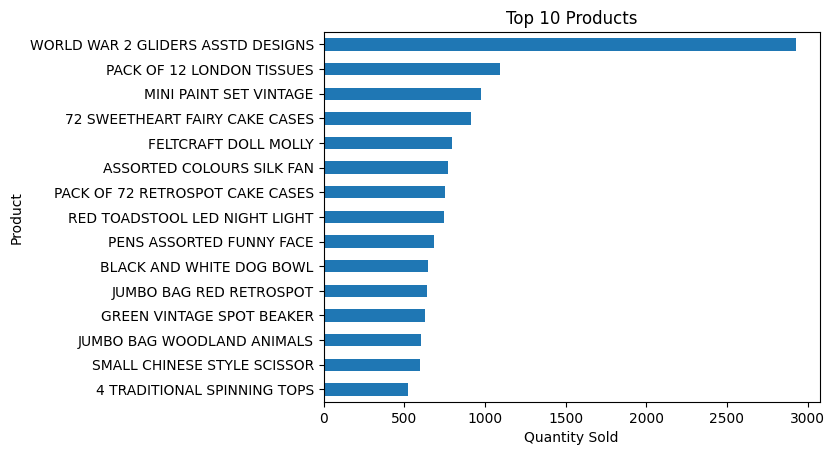

In [62]:
import matplotlib.pyplot as plt

top_products.sort_values().plot(kind="barh")

plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.title("Top 10 Products")
plt.show()

In [63]:
df.describe()

,BillNo,Quantity,Price,CustomerID
count,9956.000000,9956.000000,9956.000000,7453.000000
mean,559916.957111,10.333266,3.875246,15337.024822
std,13469.298976,33.683713,19.897175,1726.857999
min,536370.000000,1.000000,0.060000,12347.000000
25%,547960.000000,1.000000,1.250000,13991.000000
50%,560553.000000,3.000000,2.080000,15276.000000
75%,572026.500000,11.000000,4.130000,16877.000000
max,581585.000000,1728.000000,1154.670000,18287.000000


In [64]:
df['Price'].unique()

array([1.65000e+00, 8.30000e-01, 2.55000e+00, 1.25000e+00, 2.95000e+00,
       4.20000e-01, 4.65000e+00, 7.08000e+00, 5.95000e+00, 8.29000e+00,
       2.46000e+00, 3.75000e+00, 5.50000e-01, 7.46000e+00, 1.04000e+00,
       2.10000e+00, 3.36000e+00, 3.29000e+00, 1.63000e+00, 2.08000e+00,
       3.25000e+00, 4.95000e+00, 1.95000e+00, 1.57900e+01, 7.95000e+00,
       8.50000e-01, 9.95000e+00, 6.95000e+00, 1.27500e+01, 1.49000e+00,
       4.13000e+00, 4.25000e+00, 1.45000e+00, 5.45000e+00, 8.25000e+00,
       1.69000e+00, 2.90000e-01, 1.85000e+00, 4.21000e+00, 5.79000e+00,
       3.95000e+00, 1.18700e+01, 1.27200e+01, 8.50000e+00, 1.25000e+01,
       7.90000e-01, 4.96000e+00, 2.51000e+00, 7.62000e+00, 3.90000e-01,
       1.66000e+00, 1.41300e+01, 2.25000e+00, 4.15000e+00, 2.49600e+01,
       6.35000e+00, 1.90000e-01, 5.06000e+00, 7.50000e-01, 9.50000e-01,
       2.92000e+00, 6.75000e+00, 1.80000e+01, 1.69500e+01, 6.63000e+00,
       6.50000e-01, 1.46000e+00, 8.95000e+00, 2.89000e+00, 1.079

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9956 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   BillNo      9956 non-null   int64  
 1   Itemname    9956 non-null   object 
 2   Quantity    9956 non-null   int64  
 3   Date        9956 non-null   object 
 4   Price       9956 non-null   float64
 5   CustomerID  7453 non-null   float64
 6   Country     9956 non-null   object 
dtypes: float64(2), int64(2), object(3)
memory usage: 622.2+ KB


In [66]:
# Create invoice-product matrix
basket = (
    df.groupby(["BillNo", "Itemname"])["Quantity"]
    .sum()
    .unstack()
    .fillna(0)
)

# Convert quantities into binary values
# 1 = product purchased
# 0 = product not purchased

basket = basket.gt(0)

print("Basket shape:", basket.shape)


Basket shape: (5943, 2426)


In [67]:
from mlxtend.frequent_patterns import apriori

MIN_SUPPORT = 0.0001

frequent_itemsets = apriori(
    basket,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=2
)

frequent_itemsets["length"] = (
    frequent_itemsets["itemsets"].apply(len)
)

print("Frequent itemsets:", len(frequent_itemsets))
print(frequent_itemsets["length"].value_counts().sort_index())

Frequent itemsets: 12962
length
1     2426
2    10536
Name: count, dtype: int64


In [68]:


rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.01
)

print("Number of association rules:", len(rules))

display(
    rules[
        [
            "antecedents",
            "consequents",
            "support",
            "confidence",
            "lift"
        ]
    ].sort_values(
        by="lift",
        ascending=False
    ).head(20)
)

Number of association rules: 21072


,antecedents,consequents,support,confidence,lift
12256,(ICE CREAM DESIGN GARDEN PARASOL),"(GREETING CARD, OVERCROWDED POOL.)",0.000168,1.0,5943.0
11966,(WOVEN SUNSET CUSHION COVER),(GOLD M.O.P ORBIT DROP EARRINGS),0.000168,1.0,5943.0
12257,"(GREETING CARD, OVERCROWDED POOL.)",(ICE CREAM DESIGN GARDEN PARASOL),0.000168,1.0,5943.0
13990,(JIGSAW TREE WITH WATERING CAN),(PINK GREEN EMBROIDERY COSMETIC BAG),0.000168,1.0,5943.0
13991,(PINK GREEN EMBROIDERY COSMETIC BAG),(JIGSAW TREE WITH WATERING CAN),0.000168,1.0,5943.0
3879,(DAISY GARDEN MARKER),(BLUE POLKADOT LUGGAGE TAG),0.000168,1.0,5943.0
3878,(BLUE POLKADOT LUGGAGE TAG),(DAISY GARDEN MARKER),0.000168,1.0,5943.0
4831,(CAKE PLATE LOVEBIRD PINK),(WHITE AND BLUE CERAMIC OIL BURNER),0.000168,1.0,5943.0
12111,(GREEN JUICY FRUIT PHOTO FRAME),(WHITE AND BLUE CERAMIC OIL BURNER),0.000168,1.0,5943.0
12110,(WHITE AND BLUE CERAMIC OIL BURNER),(GREEN JUICY FRUIT PHOTO FRAME),0.000168,1.0,5943.0


In [69]:
def recommend_products(product_name, rules, top_n=5):

    product_name = product_name.strip()

    recommendations = rules[
        rules["antecedents"].apply(
            lambda x: product_name in x
        )
    ].copy()

    if recommendations.empty:
        recommendations = rules[
            rules["consequents"].apply(
                lambda x: product_name in x
            )
        ].copy()

        if recommendations.empty:
            return pd.DataFrame(
                columns=[
                    "Recommended Product",
                    "Confidence",
                    "Lift",
                    "Support"
                ]
            )

        recommendations["Recommended Product"] = (
            recommendations["antecedents"]
            .apply(lambda x: ", ".join(sorted(x)))
        )

    else:
        recommendations["Recommended Product"] = (
            recommendations["consequents"]
            .apply(lambda x: ", ".join(sorted(x)))
        )

    result = recommendations[
        [
            "Recommended Product",
            "confidence",
            "lift",
            "support"
        ]
    ].copy()

    result.columns = [
        "Recommended Product",
        "Confidence",
        "Lift",
        "Support"
    ]

    return result.sort_values(
        by="Lift",
        ascending=False
    ).head(top_n)

In [70]:
# Display all association rules
final_rules = rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].sort_values(
    by="lift",
    ascending=False
)

display(final_rules)

,antecedents,consequents,support,confidence,lift
12256,(ICE CREAM DESIGN GARDEN PARASOL),"(GREETING CARD, OVERCROWDED POOL.)",0.000168,1.000000,5943.000000
11966,(WOVEN SUNSET CUSHION COVER),(GOLD M.O.P ORBIT DROP EARRINGS),0.000168,1.000000,5943.000000
12257,"(GREETING CARD, OVERCROWDED POOL.)",(ICE CREAM DESIGN GARDEN PARASOL),0.000168,1.000000,5943.000000
13990,(JIGSAW TREE WITH WATERING CAN),(PINK GREEN EMBROIDERY COSMETIC BAG),0.000168,1.000000,5943.000000
13991,(PINK GREEN EMBROIDERY COSMETIC BAG),(JIGSAW TREE WITH WATERING CAN),0.000168,1.000000,5943.000000
...,...,...,...,...,...
17520,(WHITE HANGING HEART T-LIGHT HOLDER),(PARTY BUNTING),0.000168,0.027027,5.019426
14363,(LUNCH BAG BLACK SKULL.),(JUMBO BAG RED RETROSPOT),0.000168,0.037037,4.891358
14362,(JUMBO BAG RED RETROSPOT),(LUNCH BAG BLACK SKULL.),0.000168,0.022222,4.891358
14364,(LUNCH BAG SUKI DESIGN),(JUMBO BAG RED RETROSPOT),0.000168,0.034483,4.554023


In [72]:
product = (
    df.groupby("Itemname")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .index[1]
)

print("Selected product:", product)

recommend_products(
    product,
    rules,
    top_n=5
)

Selected product: PACK OF 12 LONDON TISSUES


,Recommended Product,Confidence,Lift,Support
16793,PINK CAT BOWL,0.090909,270.136364,0.000168
16794,SET OF 2 TEA TOWELS APPLE AND PEARS,0.090909,180.090909,0.000168
13070,HEART MIRROR ANTIQUE WHITE,0.090909,108.054545,0.000168
163,12 PENCILS SMALL TUBE SKULL,0.090909,90.045455,0.000168
16796,SPACEBOY BIRTHDAY CARD,0.090909,77.181818,0.000168
